**Imported the required libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime as dt
import seaborn as sns

**Loaded the dataset**

In [2]:
df=pd.read_excel('/content/online_retail_II.xlsx',sheet_name='Year 2010-2011')

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541910, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [7]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307584,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


**Checked missing values**

In [8]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


In [9]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [10]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df = df.dropna(subset=['Customer ID'])

In [12]:
df.loc[:,'Description']=df['Description'].fillna('Unkown Product')

In [13]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


**Removed invalid transactions**

In [14]:
df=df[(df['Quantity']>0) & (df['Price']>0)]

**Created Total Price**

In [15]:
df['Total_Price']=df['Quantity']*df['Price']

In [16]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


**Removed duplicates**

In [17]:
df.duplicated().sum()

np.int64(5192)

In [18]:
df.duplicated(subset=['Invoice','StockCode','Quantity','InvoiceDate','Price','Customer ID','Country']).sum()

np.int64(5194)

In [19]:
df = df.drop_duplicates()

In [20]:
df.shape

(392693, 9)

In [21]:
df.duplicated(subset=['Invoice','StockCode']).sum()

np.int64(4851)

In [22]:
df['InvoiceDate'].min()

Timestamp('2010-12-01 08:26:00')

In [23]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [24]:
today_date=dt.datetime(2011,12,9)

**Calculated Recency**

In [25]:
df.groupby('Customer ID').agg({'InvoiceDate':'max'}).head()

,InvoiceDate
Customer ID,
12346.0,2011-01-18 10:01:00
12347.0,2011-12-07 15:52:00
12348.0,2011-09-25 13:13:00
12349.0,2011-11-21 09:51:00
12350.0,2011-02-02 16:01:00


In [26]:
df['Customer ID']=df['Customer ID'].astype(int)

In [27]:
today_date-df.groupby('Customer ID').agg({'InvoiceDate':'max'}).head()

,InvoiceDate
Customer ID,
12346,324 days 13:59:00
12347,1 days 08:08:00
12348,74 days 10:47:00
12349,17 days 14:09:00
12350,309 days 07:59:00


In [28]:
temp_df=(today_date-df.groupby('Customer ID').agg({'InvoiceDate':'max'}))

In [29]:
temp_df.rename(columns={'InvoiceDate':'Recency'},inplace=True)
temp_df.head()

,Recency
Customer ID,
12346,324 days 13:59:00
12347,1 days 08:08:00
12348,74 days 10:47:00
12349,17 days 14:09:00
12350,309 days 07:59:00


In [30]:
recency_df=temp_df['Recency'].apply(lambda x: x.days)

In [31]:
recency_df.head()

,Recency
Customer ID,
12346,324
12347,1
12348,74
12349,17
12350,309


**Calculated Frequency**

In [32]:
temp_df=df.groupby(['Customer ID','Invoice']).agg({'Invoice':'count'})

In [33]:
temp_df.head()

Invoice
Customer ID Invoice         
12346       541431         1
12347       537626        31
            542237        29
            549222        24
            556201        18

In [34]:
freq_df=temp_df.groupby('Customer ID').agg({'Invoice':'sum'})
freq_df.rename(columns={'Invoice':'Frequency'},inplace=True)
freq_df.head()

,Frequency
Customer ID,
12346,1
12347,182
12348,31
12349,73
12350,17


In [35]:
df['Total_Price']=df['Total_Price'].astype(int)

**Calculated Monetary**

In [36]:
monetary_df=df.groupby('Customer ID').agg({'Total_Price':'sum'})
monetary_df.rename(columns={'Total_Price':'Monetary'},inplace=True)
monetary_df.head()

,Monetary
Customer ID,
12346,77183
12347,4251
12348,1786
12349,1718
12350,329


**Created RFM Table**

In [37]:
rfm=pd.concat([recency_df,freq_df,monetary_df],axis=1)

In [38]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,324,1,77183
12347,1,182,4251
12348,74,31,1786
12349,17,73,1718
12350,309,17,329


**Created RFM Scores**

In [39]:
rfm['Recency_score']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['Frequency_score']=pd.qcut(rfm['Frequency'],5,labels=[1,2,3,4,5])
rfm['Monetary_score']=pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])

In [40]:
rfm.head()

,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score
Customer ID,,,,,,
12346,324,1,77183,1,1,5
12347,1,182,4251,5,5,5
12348,74,31,1786,2,3,4
12349,17,73,1718,4,4,4
12350,309,17,329,1,2,2


**Created RFM Score**

In [41]:
rfm['RFM_SCORE']=(rfm['Recency_score'].astype(str)+rfm['Frequency_score'].astype(str)+rfm['Monetary_score'].astype(str))

In [42]:
rfm.head()

,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score,RFM_SCORE
Customer ID,,,,,,,
12346,324,1,77183,1,1,5,115
12347,1,182,4251,5,5,5,555
12348,74,31,1786,2,3,4,234
12349,17,73,1718,4,4,4,444
12350,309,17,329,1,2,2,122


**Customer Segmentation**

In [43]:
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Loose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

In [44]:
rfm['Segment']=rfm['Recency_score'].astype(str)+rfm['Frequency_score'].astype(str)
rfm['Segment']=rfm['Segment'].replace(seg_map,regex=True)
rfm.head()

,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score,RFM_SCORE,Segment
Customer ID,,,,,,,,
12346,324,1,77183,1,1,5,115,Hibernating
12347,1,182,4251,5,5,5,555,Champions
12348,74,31,1786,2,3,4,234,At Risk
12349,17,73,1718,4,4,4,444,Loyal Customers
12350,309,17,329,1,2,2,122,Hibernating


**Segment Statistics**

In [45]:
rfm[["Segment", "Recency","Frequency","Monetary"]].groupby("Segment").agg(["mean","count"])

Recency         Frequency           Monetary      
                           mean count        mean count         mean count
Segment                                                                   
About to Sleep        51.176471   323   15.962848   323   442.362229   323
At Risk              162.743816   566   56.779152   566   973.830389   566
Can't Loose          143.851852    81  179.592593    81  2304.703704    81
Champions              4.399007   604  285.786424   604  6826.670530   604
Hibernating          208.711111  1080   13.644444  1080   528.151852  1080
Loyal Customers       32.198286   817  154.979192   817  2764.707466   817
Need Attention        51.044118   204   41.274510   204   816.936275   204
New Customers          5.421053    57    7.578947    57  3615.350877    57
Potential Loyalists   14.629555   494   34.742915   494   892.093117   494
Promising             21.437500   112    7.758929   112   426.071429   112

In [46]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Total_Price
count,392693.000000,392693,392693.000000,392693.000000,392693.000000
mean,13.119671,2011-07-10 19:13:41.156272128,3.125952,15287.837224,22.140387
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.000000
std,180.492603,NaN,22.241820,1713.542421,311.105356


In [47]:
segment_count=rfm['Segment'].value_counts()
segment_count

,count
Segment,
Hibernating,1080
Loyal Customers,817
Champions,604
At Risk,566
Potential Loyalists,494
About to Sleep,323
Need Attention,204
Promising,112
Can't Loose,81


**Customer Distribution Chart**

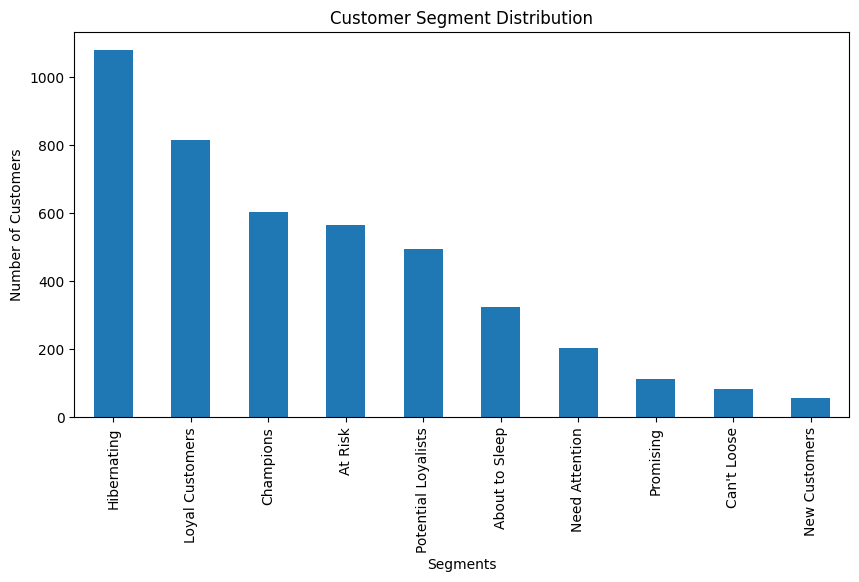

In [48]:
segment_count.plot(kind='bar',figsize=(10,5))
plt.title('Customer Segment Distribution')
plt.xlabel('Segments')
plt.ylabel('Number of Customers')
plt.show()

**Revenue Distribution**

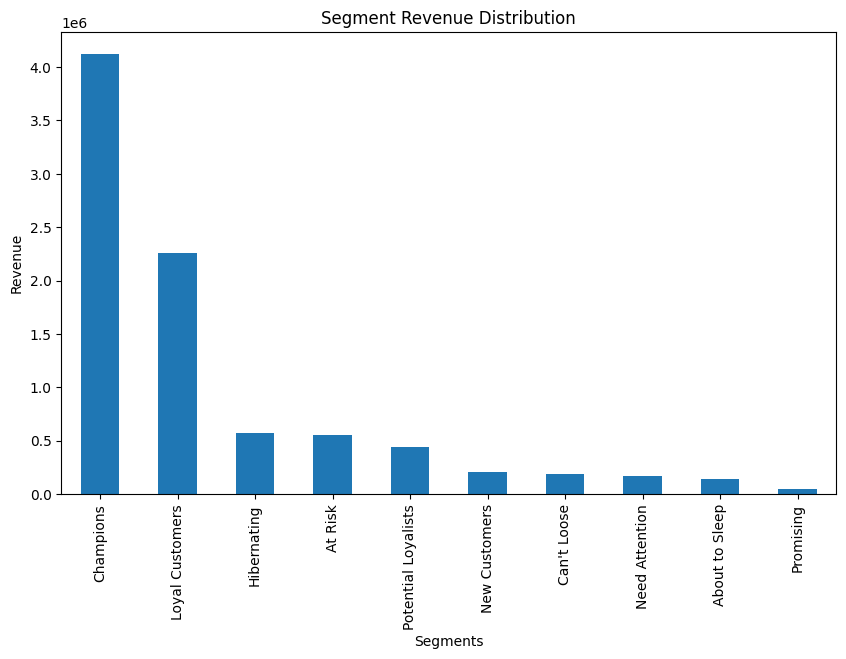

In [49]:
segment_revenue=rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_revenue.plot(kind='bar',figsize=(10,6))
plt.title('Segment Revenue Distribution')
plt.xlabel('Segments')
plt.ylabel('Revenue')
plt.show()

**RFM Heatmap**

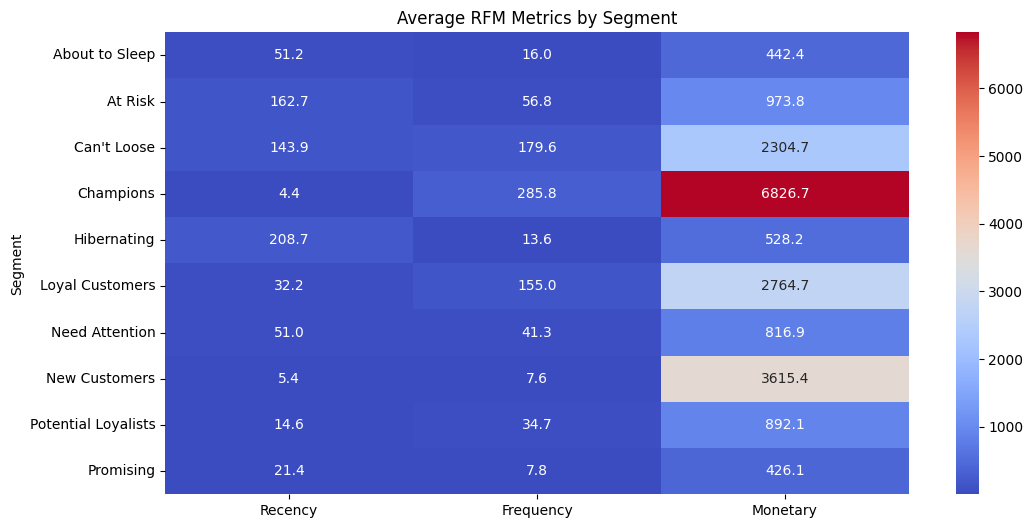

In [50]:
plt.figure(figsize=(12,6))

sns.heatmap(
    rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean(),
    annot=True,
    fmt='.1f',
    cmap='coolwarm'
)

plt.title('Average RFM Metrics by Segment')

plt.show()

In [51]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

**Cohort Analysis**

In [52]:
df['CohortMonth']=df.groupby('Customer ID')['InvoiceMonth'].transform('min')

In [53]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price,InvoiceMonth,CohortMonth
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12,2011-12,2011-08
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16,2011-12,2011-08
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16,2011-12,2011-08
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14,2011-12,2011-08
541909,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680,France,18,2011-12,2011-08


**Cohort Index**

In [54]:
df['CohortIndex']=(df['InvoiceMonth']-df['CohortMonth']).apply(lambda x: x.n)

In [55]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price,InvoiceMonth,CohortMonth,CohortIndex
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12,2011-12,2011-08,4
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16,2011-12,2011-08,4
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16,2011-12,2011-08,4
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14,2011-12,2011-08,4
541909,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680,France,18,2011-12,2011-08,4


In [56]:
cohort_data=df.groupby(['CohortMonth','CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_data.head()

,CohortMonth,CohortIndex,Customer ID
0,2010-12,0,885
1,2010-12,1,324
2,2010-12,2,286
3,2010-12,3,340
4,2010-12,4,321


**Built Cohort Table**

In [57]:
cohort_table=cohort_data.pivot(index='CohortMonth',columns='CohortIndex',values='Customer ID')
cohort_table.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN


**Retention Table**

In [58]:
retention_table=cohort_table.divide(cohort_table.iloc[:,0],axis=0)
retention_table.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


**Retention Heatmap**

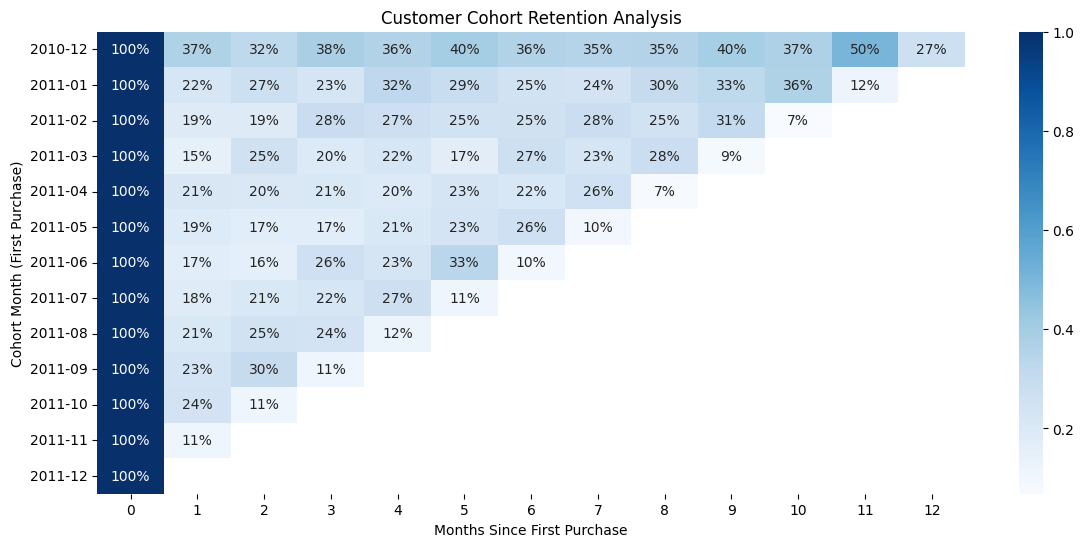

In [59]:
plt.figure(figsize=(14,6))
sns.heatmap(retention_table,annot=True,
    fmt='.0%',cmap='Blues')
plt.title('Customer Cohort Retention Analysis')
plt.ylabel('Cohort Month (First Purchase)')
plt.xlabel('Months Since First Purchase')
plt.show()

In [60]:
rfm.to_csv("rfm.csv")

In [61]:
df.to_csv("df.csv")

In [62]:
retention_table.to_csv("retention.csv")